In [308]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

In [309]:
class healthState(TypedDict):
    height: float
    weight: float
    age: int
    gender: Literal['m', 'f']
    bmi: float
    bmr: float
    ideal_weight: float
    protein_intake: float
    summary: str
    


In [310]:
def input_state(state: healthState) -> healthState:
    return state

In [311]:
def calculate_bmi(state: healthState) -> healthState:
    height_m = state['height'] * 0.0254   # Convert height to meters
    bmi = state['weight'] / (height_m ** 2)
    
    return {'bmi': bmi}

In [312]:
def calculate_bmr(state: healthState) -> healthState:
    if state['gender'] == 'm':
        bmr = 88.362 + (13.397 * state['weight']) + (4.799 * state['height']) - (5.677 * state['age'])
    else:
        bmr = 447.593 + (9.247 * state['weight']) + (3.098 * state['height']) - (4.330 * state['age'])  
    return {'bmr': bmr}

In [313]:
def calculate_ideal_weight(state: healthState) -> healthState:
    if state['gender'] == 'm':
        ideal_weight = 50 + 2.3 * ((state['height'] * 0.0254 * 39.37) - 60)  # Convert height to inches 
    else:
        ideal_weight = 45.5 + 2.3 * ((state['height'] * 0.0254 * 39.37) - 60)  # Convert height to inches
    return {'ideal_weight': ideal_weight}

In [314]:
def calculate_protein_intake(state: healthState) -> healthState:
    protein_intake = state['weight'] * 0.8  # 0.8 grams of protein per kg of body weight
    return {'protein_intake': protein_intake}

In [315]:
def health_summary(state: healthState) -> healthState:
    summary=f"""Your BMI is {state['bmi']:.2f}, Your BMR is {state['bmr']:.2f} Calories/Day, Your ideal weight is {state['weight']:.2f} kg,  And your recommended daily protein intake is {state['protein_intake']:.2f} grams."""
    return {'summary': summary}

In [316]:
graph = StateGraph(healthState)

# Add nodes
graph.add_node('input_state', input_state)
graph.add_node('calculate_bmi', calculate_bmi)
graph.add_node('calculate_bmr', calculate_bmr) 
graph.add_node('calculate_ideal_weight', calculate_ideal_weight)
graph.add_node('calculate_protein_intake', calculate_protein_intake)
graph.add_node('summary', health_summary)


graph.add_edge(START, 'input_state')
graph.add_edge('input_state', 'calculate_bmi')
graph.add_edge('input_state', 'calculate_bmr')
graph.add_edge('input_state', 'calculate_ideal_weight')
graph.add_edge('input_state', 'calculate_protein_intake')


graph.add_edge('calculate_bmi', 'summary')
graph.add_edge('calculate_bmr', 'summary')
graph.add_edge('calculate_ideal_weight', 'summary')
graph.add_edge('calculate_protein_intake', 'summary')

graph.add_edge('summary', END)

workflow = graph.compile()

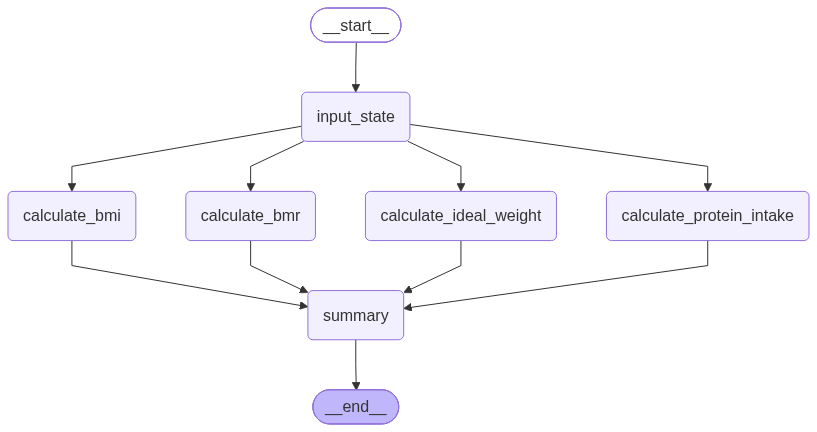

In [317]:
workflow


In [324]:
initial_state = {
    'height': 69,  # in inches
    'weight': 80,  # in kg
    'age': 30,
    'gender': 'm',
}

In [325]:
final_state = workflow.invoke(initial_state)

In [326]:
print(f"Your Height: {final_state['height']:.2f} Inches")
print(f"Your Weight: {final_state['weight']:.2f} KG")
print(f"Your Age: {final_state['age']} Years")
if final_state['gender']=='m':
    print(f"Your Gender: Male")
else:
    print(f"Your Gender: Female")   
print(f"Your BMI: {final_state['bmi']:.2f}")
print(f"Your BMR: {final_state['bmr']:.2f} Calories/Day")
print(f"Your Ideal Weight: {final_state['ideal_weight']:.2f} KG")
print(f"Your Recommendaded Protein Intake: {final_state['protein_intake']:.2f} Grams")
print(f"Your Health Summary: {final_state['summary']}")


Your Height: 69.00 Inches
Your Weight: 80.00 KG
Your Age: 30 Years
Your Gender: Male
Your BMI: 26.05
Your BMR: 1320.94 Calories/Day
Your Ideal Weight: 70.70 KG
Your Recommendaded Protein Intake: 64.00 Grams
Your Health Summary: Your BMI is 26.05, Your BMR is 1320.94 Calories/Day, Your ideal weight is 80.00 kg,  And your recommended daily protein intake is 64.00 grams.
